In [1]:
import matplotlib.pyplot as plt
import numpy as np
import arc
import pairinteraction as pi
if pi.Database.get_global_database() is None:
    pi.Database.initialize_global_database(download_missing=False)
import os
from IPython.display import Latex
import scipy
import pandas as pd
from pandas import DataFrame
h = scipy.constants.h
epsilon_0 = scipy.constants.epsilon_0
a_0 = scipy.constants.physical_constants['Bohr radius']
e = scipy.constants.e


In [2]:
import os
np.set_printoptions(legacy='1.25')
if pi.Database.get_global_database() is None:
    pi.Database.initialize_global_database(download_missing=False)
atom1, atom2 = 'Rb', 'Cs'
colours = ('orange', 'green', 'red', 'blue')
orbs = ('s', 'p', 'd', 'f')
difs = np.arange(-8,9)
changes = np.arange(-3, 4)
energy_unit = 'GHz'

min_n = 30
max_n = 120
ns = np.arange(min_n,max_n)
preferQuantumDefects = True


js = [[1/2], [1/2, 3/2], [3/2, 5/2], [5/2, 7/2]]

l1, l2 = 2, 2


for j1 in js[l1]:
    for j2 in js[l2]:
        for l1_1 in (l1-1, l1+1):
            if l1_1 < 0:
                continue
            for l2_1 in (l1-1, l2+1):
                if l2_1 < 0:
                    continue
                
                for dif in difs:
                    for change1 in changes:
                        
                        for change2 in changes:
                            jpdelta = []
                            labels = []
                            
                            for j1_1 in js[l1_1]:
                                if abs(j1_1 - j1) > 1:
                                    continue

                                for j2_1 in js[l2_1]: 
                                    if abs(j2_1 - j2) > 1:
                                        continue 
                                    path = fr'C:\\Users\\tommy\\OneDrive - Durham University\\level 4 Project\\data\\defects\\{atom1}{atom2}\\{orbs[l1]}{orbs[l2]}\\j1j2({j1},{j2})\\to {orbs[l1_1]}{orbs[l2_1]}\\'
                                    if not os.path.exists(path):
                                        os.makedirs(path)
                                    elif os.path.exists(path + f'{j1_1}, {j2_1} {dif} {change1} {change2}.csv'):
                                        continue
                                    # print(f'l1 {l1}, j1 {j1} -> l1_1 {l1_1}, j1_1 {j1_1}') 
                                    # print(f'change1 {change1}, change2 {change2}, dif {dif}') 
                                    delta = []


                                    for n in ns:
                                        nb = n+dif
                                        
                                        # Rb lowering n
                                        ket1 = pi.KetAtom(atom1, n=n, l=l1, j=j1, m=j1, s=1/2)
                                        ket2 = pi.KetAtom(atom2, n=nb, l=l2, j=j2, m=j2, s=1/2)
                                        ket1_1 = pi.KetAtom(atom1, n=n+change1, l=l1_1, j=j1_1, m=j1_1, s=1/2)
                                        ket2_1 = pi.KetAtom(atom2, n=nb+change2, l=l2_1, j=j2_1, m=j2_1, s=1/2)
                                        
                                        defect_1 = ket1_1.get_energy(energy_unit) - ket1.get_energy(energy_unit)
                                        defect_2 = ket2_1.get_energy(energy_unit) - ket2.get_energy(energy_unit)
                                        defect = defect_1 + defect_2
                                        delta.append(defect)
                                    
                                    defect_data = pd.DataFrame({'n' : ns, 'defect' : delta})
                                    
                                    
                                    # os.path.join(path + f'j1_1, j2_1 dif  change1  change2.txt')
                                    if not os.path.exists(path + 'j1_1, j2_1 dif  change1  change2.txt'):
                                        with open(path + 'j1_1, j2_1 dif  change1  change2.txt', "w") as file:
                                            file.write("")

                                    defect_data.to_csv(path + f'{j1_1}, {j2_1} {dif} {change1} {change2}.csv', index=False)
                        print(f'j1s: {int(list(js[l1]).index(j1)/len(js[l1])*100)}% | j2s: {int(list(js[l2]).index(j2)/len(js[l2])*100)}% | l1_1, l2_1: {l1_1},{l2_1} | difs: {int(list(difs).index(dif)/len(difs)*100)}% | change1 {int(list(changes).index(change1)/len(changes)*100)}%')
                                    
                                    

j1s: 0% | j2s: 0% | l1_1, l2_1: 1,1 | difs: 0% | change1 0%
j1s: 0% | j2s: 0% | l1_1, l2_1: 1,1 | difs: 0% | change1 14%
j1s: 0% | j2s: 0% | l1_1, l2_1: 1,1 | difs: 0% | change1 28%
j1s: 0% | j2s: 0% | l1_1, l2_1: 1,1 | difs: 0% | change1 42%
j1s: 0% | j2s: 0% | l1_1, l2_1: 1,1 | difs: 0% | change1 57%
j1s: 0% | j2s: 0% | l1_1, l2_1: 1,1 | difs: 0% | change1 71%
j1s: 0% | j2s: 0% | l1_1, l2_1: 1,1 | difs: 0% | change1 85%
j1s: 0% | j2s: 0% | l1_1, l2_1: 1,1 | difs: 5% | change1 0%
j1s: 0% | j2s: 0% | l1_1, l2_1: 1,1 | difs: 5% | change1 14%
j1s: 0% | j2s: 0% | l1_1, l2_1: 1,1 | difs: 5% | change1 28%
j1s: 0% | j2s: 0% | l1_1, l2_1: 1,1 | difs: 5% | change1 42%
j1s: 0% | j2s: 0% | l1_1, l2_1: 1,1 | difs: 5% | change1 57%
j1s: 0% | j2s: 0% | l1_1, l2_1: 1,1 | difs: 5% | change1 71%
j1s: 0% | j2s: 0% | l1_1, l2_1: 1,1 | difs: 5% | change1 85%
j1s: 0% | j2s: 0% | l1_1, l2_1: 1,1 | difs: 11% | change1 0%
j1s: 0% | j2s: 0% | l1_1, l2_1: 1,1 | difs: 11% | change1 14%
j1s: 0% | j2s: 0% | l1_1,

C:\Users\Tommy\AppData\Local\Temp\ipykernel_7236\1376218586.py:30: RuntimeWarning: divide by zero encountered in log10
  cmap = ax.imshow(np.log10(Z), cmap=alphamagma.reversed(), extent=(-.5, n_max+.5, -0.5, n_max+0.5), origin='lower')


[]


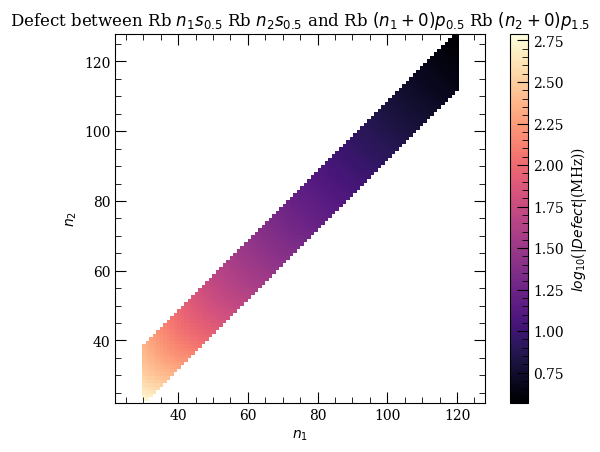

In [31]:
from pairinteraction.visualization.colormaps import alphamagma
l1, l2 = 0, 0
j1, j2 = 1/2, 1/2
l1_1, l2_1 = 1, 1
j1_1, j2_1 = 1/2, 3/2

change1, change2 = 0,0
max_dif = 8
min_dif = -8

plot_n1s=[]
plot_n2s=[]
fig, ax = plt.subplots()
ax.set_aspect('equal', adjustable='box')
n_max = max_n + max_dif
n_min = min_n + min_dif
Z = np.zeros((n_max, n_max))
for dif in range (-8, 9):
    defect_path = fr'C:\\Users\\tommy\\OneDrive - Durham University\\level 4 Project\\data\\defects\\{atom1}{atom2}\\{orbs[l1]}{orbs[l2]}\\j1j2({j1},{j2})\\to {orbs[l1_1]}{orbs[l2_1]}\\{j1_1}, {j2_1} {dif} {change1} {change2}.csv'
    data = pd.read_csv(defect_path)
    defects = data['defect'].to_numpy()
    n1_0s = data['n'].to_numpy()
    for n, defect in zip(n1_0s, defects):
        Z[n + dif, n] = defect


# print(Z)
ax.set_aspect('equal', adjustable='box')

cmap = ax.imshow(np.log10(Z), cmap=alphamagma.reversed(), extent=(-.5, n_max+.5, -0.5, n_max+0.5), origin='lower')

col = 0
# for l1_1 in [l1-1, l1+1]:
#     for l2_1 in [l2-1, l1+1]:
#         path = fr'C:\\Users\\tommy\\OneDrive - Durham University\\level 4 Project\\Data\\spreadsheets\\{atom1}{atom2}\\{orbs[l1]}{orbs[l2]} to {orbs[l1_1]}{orbs[l2_1]} j1j2({j1},{j2}).xlsx'
#         if os.path.exists(path):
#             df = pd.read_excel(path)
#             plot_n1s = df['n1_0'].to_numpy()
#             plot_n2s = df['n2_0'].to_numpy()
#             ax.plot(plot_n1s, plot_n2s, 'o', markerfacecolor='none', markersize=8, color=colours[col], markeredgewidth=2, label = f'{orbs[l1_1]} {orbs[l2_1]}')
#             col+=1
#         else:
#             continue
# print(df['n1_0'])
# np.concatenate(plot_n1s).flatten()
# np.concatenate(plot_n2s).flatten()
print(plot_n1s)

# plt.legend()

cbar = plt.colorbar(cmap, label=r'$log_{10}$(|$Defect$|(MHz))')
# cbar.set_ticks(np.arange(-2,6))
plt.xlabel(r'$n_1$')
plt.ylabel(r'$n_2$')
plt.ylim(n_min, n_max)
plt.xlim(n_min, n_max)
plt.title(rf'Defect between {atom1} $n_1{orbs[l1]}_{{{j1}}}$ {atom2} $n_2{orbs[l2]}_{{{j2}}}$ and {atom1} $(n_1+{change1}){orbs[l1_1]}_{{{j1_1}}}$ {atom2} $(n_2+{change2}){orbs[l2_1]}_{{{j2_1}}}$')
plt.show()